In [1]:
import pandas as pd 
import numpy as np
import os
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

## Convert YOLO Dataset to Classification Dataset

In [2]:
import os
import shutil

# Source folders
image_dir = r"C:\Users\yadun\Desktop\Abhinand\final Project\data\images"
label_dir = r"C:\Users\yadun\Desktop\Abhinand\final Project\data\labels"

# Destination folder
output_dir = r"C:\Users\yadun\Desktop\Abhinand\final Project\classification_dataset"

classes = {
    0: "pothole",
    1: "no_pothole",
    2: "manmade_pothole"
}

# Create class folders
for cls in classes.values():
    os.makedirs(os.path.join(output_dir, cls), exist_ok=True)

# Copy images into corresponding class folders
for label_file in os.listdir(label_dir):

    if not label_file.endswith(".txt"):
        continue

    label_path = os.path.join(label_dir, label_file)

    with open(label_path, "r") as f:
        line = f.readline().strip()

    if line == "":
        continue

    class_id = int(line.split()[0])

    image_name = label_file.replace(".txt", ".jpg")
    image_path = os.path.join(image_dir, image_name)

    if os.path.exists(image_path):
        shutil.copy(
            image_path,
            os.path.join(output_dir, classes[class_id], image_name)
        )

print("Dataset Created Successfully")

Dataset Created Successfully


In [3]:
!pip install split-folders

## Split into Train, Validation, and Test

In [4]:
import splitfolders

splitfolders.ratio(
    r"C:\Users\yadun\Desktop\Abhinand\final Project\classification_dataset",
    output=r"C:\Users\yadun\Desktop\Abhinand\final Project\road_dataset",
    seed=42,
    ratio=(0.8, 0.1, 0.1)
)

Copying files: 2009 files [00:02, 918.33 files/s]


## Load the dataset

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = r"C:\Users\yadun\Desktop\Abhinand\final Project\road_dataset\train"
val_dir = r"C:\Users\yadun\Desktop\Abhinand\final Project\road_dataset\val"
test_dir = r"C:\Users\yadun\Desktop\Abhinand\final Project\road_dataset\test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print(train_generator.class_indices)

Found 1605 images belonging to 3 classes.
Found 200 images belonging to 3 classes.
Found 204 images belonging to 3 classes.
{'manmade_pothole': 0, 'no_pothole': 1, 'pothole': 2}


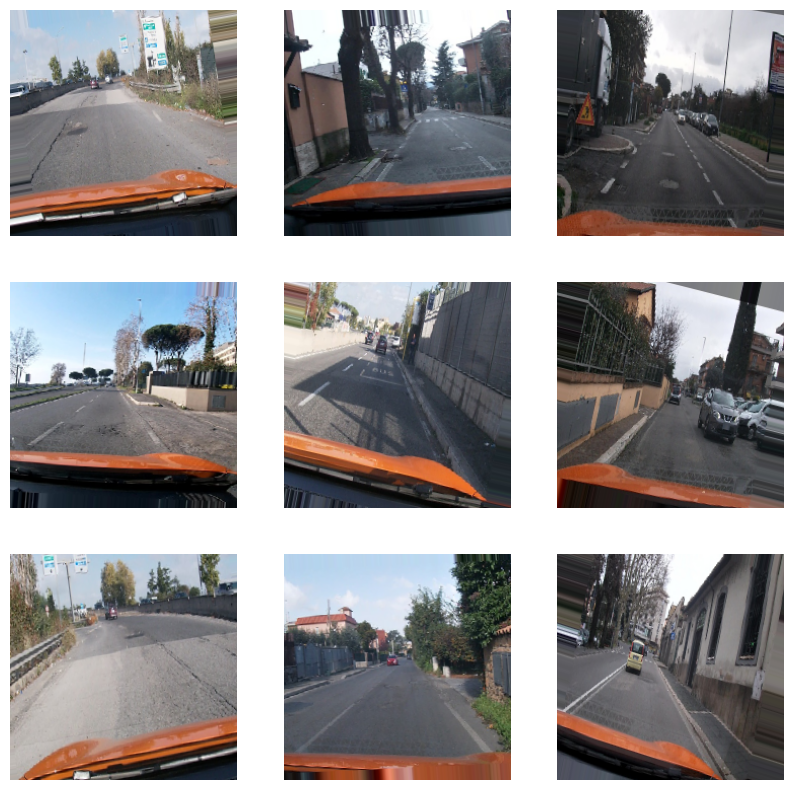

In [6]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

## Baseline CNN Model

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

cnn_model = Sequential([

    Conv2D(32,(3,3),activation='relu',
           input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(train_generator.num_classes,
          activation='softmax')
])

cnn_model.summary()

C:\Users\yadun\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      22,151,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,245,443 (84.86 MB)

 Trainable params: 22,245,443 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.2384259259259258), 1: np.float64(0.6679151061173533), 2: np.float64(1.4381720430107527)}


In [11]:
history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights
)

Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.2748 - loss: 1.1649 - val_accuracy: 0.2700 - val_loss: 1.1024
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 51s 996ms/step - accuracy: 0.2710 - loss: 1.0988 - val_accuracy: 0.2700 - val_loss: 1.1013
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 51s 995ms/step - accuracy: 0.2760 - loss: 1.0986 - val_accuracy: 0.2700 - val_loss: 1.0993
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 548s 11s/step - accuracy: 0.3308 - loss: 1.0981 - val_accuracy: 0.5000 - val_loss: 1.0377
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 45s 879ms/step - accuracy: 0.3919 - loss: 1.0917 - val_accuracy: 0.3500 - val_loss: 1.0713
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 46s 890ms/step - accuracy: 0.3589 - loss: 1.0879 - val_accuracy: 0.3950 - val_loss: 1.0756
Epoch 7/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 51s 992ms/step - accuracy: 0.3931 - loss: 1.0732 - val_accuracy: 0.4600 - val_loss: 0.9962
Epoch 8/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 51s 998ms/step - accuracy: 0.4112 - loss: 1.0700 - val_accuracy

In [12]:
loss, accuracy = cnn_model.evaluate(test_generator)

print("Accuracy :",accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 439ms/step - accuracy: 0.4559 - loss: 1.0838
Accuracy : 0.45588234066963196


In [13]:
import numpy as np

pred = cnn_model.predict(test_generator)

predicted_classes = np.argmax(pred,axis=1)

true_classes = test_generator.classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 236ms/step


In [14]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(
    true_classes,
    predicted_classes
)

print("Accuracy :",acc)

Accuracy : 0.45588235294117646


In [15]:
from sklearn.metrics import precision_score

precision = precision_score(
    true_classes,
    predicted_classes,
    average='weighted'
)

print("Precision :",precision)

Precision : 0.5017997573360895


In [16]:
from sklearn.metrics import recall_score

recall = recall_score(
    true_classes,
    predicted_classes,
    average='weighted'
)

print("Recall :",recall)

Recall : 0.45588235294117646


In [17]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=list(train_generator.class_indices.keys())
))

                 precision    recall  f1-score   support

manmade_pothole       0.48      0.22      0.30        55
     no_pothole       0.58      0.45      0.51       101
        pothole       0.35      0.75      0.48        48

       accuracy                           0.46       204
      macro avg       0.47      0.47      0.43       204
   weighted avg       0.50      0.46      0.44       204



In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

print(cm)

[[12 23 20]
 [10 45 46]
 [ 3  9 36]]


In [19]:
cnn_model.save("baseline_cnn.keras")

## Build the Model (Recommended: MobileNetV2)

In [38]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

predictions = Dense(
    train_generator.num_classes,
    activation="softmax"
)(x)

mobilenet_model = Model(base_model.input, predictions)

## compile 

In [39]:
mobilenet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [40]:
history_mobile = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.5589 - loss: 0.9691 - val_accuracy: 0.5250 - val_loss: 0.9536
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.5632 - loss: 0.9375 - val_accuracy: 0.5700 - val_loss: 0.8855
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.5688 - loss: 0.9520 - val_accuracy: 0.5800 - val_loss: 0.8728
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.5607 - loss: 0.9329 - val_accuracy: 0.5500 - val_loss: 0.9081
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.5645 - loss: 0.9313 - val_accuracy: 0.5850 - val_loss: 0.8868
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.5508 - loss: 0.9420 - val_accuracy: 0.5750 - val_loss: 0.8624
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.5732 - loss: 0.9231 - val_accuracy: 0.5850 - val_loss: 0.8611
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.5639 - loss: 0.9234 - val_accuracy: 0.5750 - val_loss:

In [41]:
pred = mobilenet_model.predict(test_generator) 

predicted_classes = np.argmax(pred,axis=1)

true_classes = test_generator.classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 923ms/step


In [57]:
mobilenet_model.save("mobilenet.keras")

## ResNet50

In [24]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable=False

x=GlobalAveragePooling2D()(base_model.output)
x=Dropout(0.3)(x)

output=Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

resnet_model=Model(base_model.input,output)

In [25]:
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
history_resnet = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.3377 - loss: 1.2185 - val_accuracy: 0.5000 - val_loss: 1.0645
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.3196 - loss: 1.1531 - val_accuracy: 0.4100 - val_loss: 1.0623
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.3570 - loss: 1.1359 - val_accuracy: 0.2800 - val_loss: 1.0863
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.3308 - loss: 1.1240 - val_accuracy: 0.2700 - val_loss: 1.1300
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.3458 - loss: 1.1125 - val_accuracy: 0.3400 - val_loss: 1.0951
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.3389 - loss: 1.1115 - val_accuracy: 0.5000 - val_loss: 1.0255
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.3894 - loss: 1.1045 - val_accuracy: 0.4150 - val_loss: 1.0698
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 680s 14s/step - accuracy: 0.3707 - loss: 1.0992 - val_accuracy: 0.3550 - val_lo

In [ ]:
resnet_model.save("resnet50.keras")

##  EfficientNetB0

In [28]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable=False

x=GlobalAveragePooling2D()(base_model.output)
x=Dropout(0.3)(x)

output=Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

efficientnet_model=Model(base_model.input,output)

In [29]:
efficientnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
history_eff = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.3296 - loss: 1.1313 - val_accuracy: 0.2700 - val_loss: 1.1582
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.3421 - loss: 1.1176 - val_accuracy: 0.2300 - val_loss: 1.1561
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.3470 - loss: 1.1264 - val_accuracy: 0.2300 - val_loss: 1.1273
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.3072 - loss: 1.1179 - val_accuracy: 0.2300 - val_loss: 1.1149
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.3171 - loss: 1.1271 - val_accuracy: 0.2300 - val_loss: 1.1610
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.3259 - loss: 1.1134 - val_accuracy: 0.2300 - val_loss: 1.1197
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.3290 - loss: 1.1104 - val_accuracy: 0.2700 - val_loss: 1.0978
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.3315 - loss: 1.1154 - val_accuracy: 0.5000 - val_loss:

In [55]:
efficientnet_model.save("efficientnet.keras")

## Model Comparison 

In [33]:
from sklearn.metrics import (
    f1_score
)
def evaluate_model(model, test_generator):

    test_generator.reset()

    predictions = model.predict(test_generator)

    y_pred = np.argmax(predictions, axis=1)
    y_true = test_generator.classes

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    return accuracy, precision, recall, f1

In [52]:
cnn_acc, cnn_pre, cnn_rec, cnn_f1 = evaluate_model(
    cnn_model,
    test_generator
)

mobile_acc, mobile_pre, mobile_rec, mobile_f1 = evaluate_model(
    mobilenet_model,
    test_generator
)

resnet_acc, resnet_pre, resnet_rec, resnet_f1 = evaluate_model(
    resnet_model,
    test_generator
)

efficient_acc, efficient_pre, efficient_rec, efficient_f1 = evaluate_model(
    efficientnet_model,
    test_generator
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 518ms/step


C:\Users\yadun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 616ms/step


C:\Users\yadun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [53]:
comparison = pd.DataFrame({

    "Model":[
        "CNN",
        "MobileNetV2",
        "ResNet50",
        "EfficientNetB0"
    ],

    "Accuracy":[
        cnn_acc,
        mobile_acc,
        resnet_acc,
        efficient_acc
    ],

    "Precision":[
        cnn_pre,
        mobile_pre,
        resnet_pre,
        efficient_pre
    ],

    "Recall":[
        cnn_rec,
        mobile_rec,
        resnet_rec,
        efficient_rec
    ],

    "F1 Score":[
        cnn_f1,
        mobile_f1,
        resnet_f1,
        efficient_f1
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,CNN,0.455882,0.501800,0.455882,0.444154
1,MobileNetV2,0.500000,0.351985,0.500000,0.396228
2,ResNet50,0.299020,0.164426,0.299020,0.189771
3,EfficientNetB0,0.235294,0.055363,0.235294,0.089636


In [54]:
model.save("road_damage_classifier.keras")

#### Through the analysis MobileNetV2 is consider as the best for model building 